Vania dos Santos -
Projeto Digital Twin Motor


Digital Twin: Monitoramento e Ajuste Dinâmico de Operação


# Projeto de Gêmeo Digital para Esteira de Produção

Este projeto simula uma esteira de produção industrial onde a lógica de Python classifica o perfil do operador (Iniciante ou Veterano) com base no tempo de processamento e ajusta automaticamente o RPM do motor.

Foram simuladas variáveis como:

- Temperatura
- Vibração
- Velocidade
- Corrente elétrica
- Tamanho da fila

O objetivo é analisar o comportamento da esteira e prever possíveis falhas com base nos sensores.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração para os gráficos aparecerem bonitos no Colab
%matplotlib inline
sns.set_theme(style="whitegrid")

In [ ]:
# quantidade de registros simulados
num_registros = 200

# horário inicial
tempo_inicial = datetime.now()

# lista que armazenará os dados
dados = []

# fila inicial
fila = 0

In [ ]:
for i in range(num_registros):

    timestamp = tempo_inicial + timedelta(seconds=i * 10)

    # itens chegando na esteira
    itens_chegando = np.random.randint(8, 13)

    # itens processados
    itens_processados = np.random.randint(7, 12)

    # cálculo da fila
    fila = max(0, fila + itens_chegando - itens_processados)

    # sensores simulados
    temperature = np.random.normal(70, 5)
    vibration = np.random.normal(8, 2)
    speed = np.random.normal(50, 5)
    current = np.random.normal(15, 3)

    # cálculo de falha
    failure_score = 0

    if temperature > 74:
        failure_score += 1

    if vibration > 8.5:
        failure_score += 1

    if current > 16:
        failure_score += 1

    if speed < 49:
        failure_score += 1

    failure = 1 if failure_score >= 2 else 0

    # adiciona os dados na lista
    dados.append({
        "timestamp": timestamp,
        "queue": fila,
        "temperature": round(temperature, 2),
        "vibration": round(vibration, 2),
        "speed": round(speed, 2),
        "current": round(current, 2),
        "failure": failure
    })

⚙️ Módulo: Risk Classifier (Classificação de Operador)

Este script implementa a inteligência de um Digital Twin para monitoramento de linha de produção. A lógica analisa o desempenho individual e aplica ajustes preditivos no motor para garantir a eficiência operacional.

In [1]:
def classify_operator_and_set_rpm(processing_time):
    if processing_time > 5:
        perfil = "Iniciante"
        rpm_sugerido = 800
    else:
        perfil = "Veterano"
        rpm_sugerido = 1200
    return perfil, rpm_sugerido

# Dados de teste para demonstração (Linha separada)
test_data = [6.2, 4.5, 3.8, 7.1]

print(f"{'Tempo (s)':<10} | {'Perfil':<12} | {'RPM Ajustado'}")
print("-" * 40)

# O "for" precisa começar em uma linha nova (Linha separada)
for time in test_data:
    perfil, rpm = classify_operator_and_set_rpm(time)
    print(f"{time:<10} | {perfil:<12} | {rpm} RPM")

Tempo (s)  | Perfil       | RPM Ajustado
----------------------------------------
6.2        | Iniciante    | 800 RPM
4.5        | Veterano     | 1200 RPM
3.8        | Veterano     | 1200 RPM
7.1        | Iniciante    | 800 RPM


Geração dos Dados Simulados
Nesta etapa, foram simulados 200 registros de funcionamento de uma esteira de produção.

Para cada registro, foram geradas informações como:

Temperatura
Vibração
Velocidade
Corrente elétrica
Tamanho da fila de produção
Também foi criada uma variável chamada failure, responsável por indicar possíveis falhas no sistema.

A falha é marcada quando pelo menos dois sensores apresentam comportamento anormal ao mesmo tempo.


In [ ]:
# cria o DataFrame
df = pd.DataFrame(dados)

# exibe as primeiras linhas
df.head()

,timestamp,queue,temperature,vibration,speed,current,failure
0,2026-03-30 21:50:33.225736,0,71.87,8.29,50.13,15.99,0
1,2026-03-30 21:50:43.225736,1,68.39,10.19,54.57,11.65,0
2,2026-03-30 21:50:53.225736,2,64.33,9.61,49.01,18.23,1
3,2026-03-30 21:51:03.225736,3,68.55,5.20,44.73,16.41,1
4,2026-03-30 21:51:13.225736,4,70.54,9.45,38.03,16.29,1


## Visualização Inicial dos Dados

Agora os dados estão organizados em um DataFrame.

A tabela abaixo mostra os primeiros registros simulados, permitindo verificar se todas as colunas foram criadas corretamente.

## Informações Gerais do Dataset

Nesta etapa, são exibidas informações sobre as colunas do dataset, tipos de dados e estatísticas gerais.

Isso ajuda a entender a distribuição dos sensores e identificar possíveis inconsistências.

In [ ]:
# informações gerais do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   timestamp    200 non-null    datetime64[ns]
 1   queue        200 non-null    int64         
 2   temperature  200 non-null    float64       
 3   vibration    200 non-null    float64       
 4   speed        200 non-null    float64       
 5   current      200 non-null    float64       
 6   failure      200 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(2)
memory usage: 11.1 KB


In [ ]:
# estatísticas descritivas
df.describe()

,timestamp,queue,temperature,vibration,speed,current,failure
count,200,200.000000,200.00000,200.000000,200.000000,200.000000,200.000000
mean,2026-03-30 22:07:08.225735680,90.870000,69.76710,8.089200,50.306550,14.570750,0.375000
min,2026-03-30 21:50:33.225736,0.000000,57.25000,3.470000,34.070000,5.950000,0.000000
25%,2026-03-30 21:58:50.725735936,45.750000,66.86250,6.792500,47.002500,12.235000,0.000000
50%,2026-03-30 22:07:08.225735936,95.000000,69.66000,8.125000,50.585000,14.735000,0.000000
75%,2026-03-30 22:15:25.725735936,136.250000,73.09250,9.162500,54.145000,16.370000,1.000000
max,2026-03-30 22:23:43.225736,182.000000,81.66000,13.980000,60.940000,21.490000,1.000000
std,NaN,52.965648,4.75088,1.896281,5.086866,2.889308,0.485338


## Análise Visual dos Sensores

Os gráficos ajudam a entender como os sensores se comportam ao longo do tempo.

Nesta etapa, serão analisadas variáveis como temperatura, vibração e tamanho da fila.

Gráfico de temperatura:

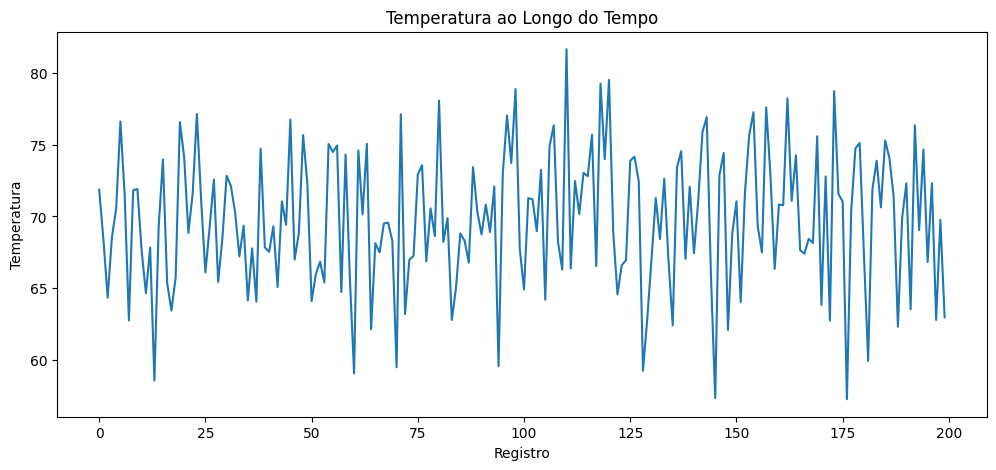

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(df["temperature"])
plt.title("Temperatura ao Longo do Tempo")
plt.xlabel("Registro")
plt.ylabel("Temperatura")
plt.show()

Vibração:

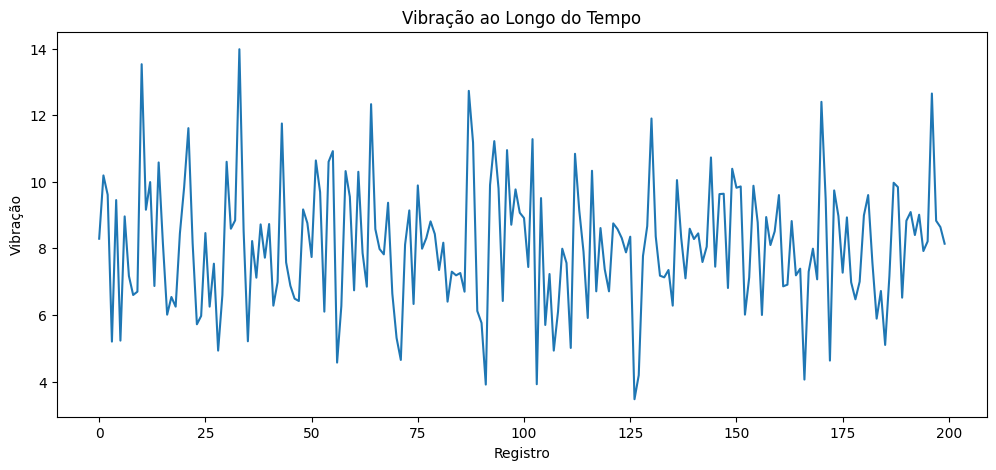

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(df["vibration"])
plt.title("Vibração ao Longo do Tempo")
plt.xlabel("Registro")
plt.ylabel("Vibração")
plt.show()

Fila:

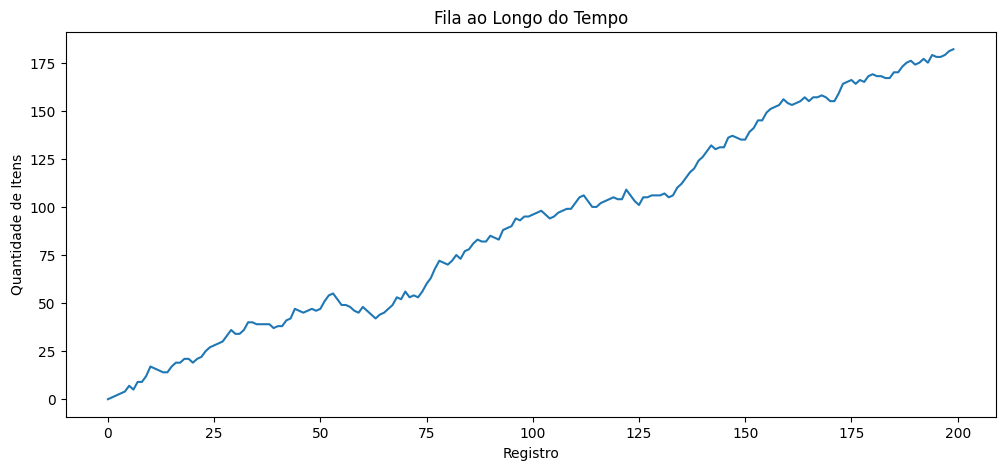

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(df["queue"])
plt.title("Fila ao Longo do Tempo")
plt.xlabel("Registro")
plt.ylabel("Quantidade de Itens")
plt.show()

 Distribuição dos Sensores

Além de observar os sensores ao longo do tempo, também é importante analisar como os valores estão distribuídos.

Os histogramas ajudam a entender quais faixas de valores aparecem com mais frequência.

Histograma de temperatura:

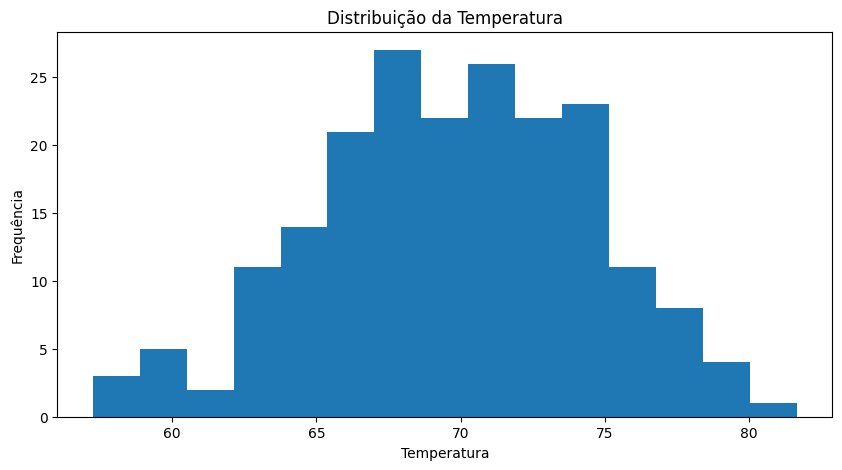

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(df["temperature"], bins=15)
plt.title("Distribuição da Temperatura")
plt.xlabel("Temperatura")
plt.ylabel("Frequência")
plt.show()

Vibração:

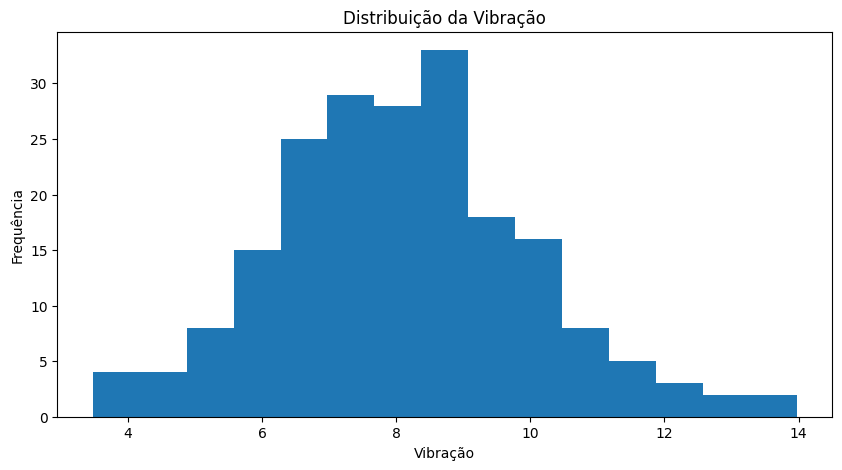

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(df["vibration"], bins=15)
plt.title("Distribuição da Vibração")
plt.xlabel("Vibração")
plt.ylabel("Frequência")
plt.show()

Análise das Falhas

Nesta etapa, será analisada a quantidade de registros com falha e sem falha.

Isso ajuda a entender se o dataset está equilibrado e se existem dados suficientes para treinar um modelo preditivo.

In [ ]:
df["failure"].value_counts()

,count
failure,
0,125
1,75


Observa-se que o dataset possui registros de funcionamento normal e registros com falha.

Esse equilíbrio é importante porque permite que futuros modelos de machine learning aprendam tanto os padrões normais quanto os comportamentos anormais da esteira.

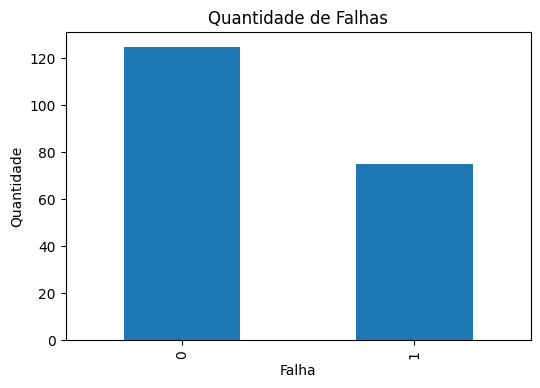

In [ ]:
plt.figure(figsize=(6, 4))
df["failure"].value_counts().plot(kind="bar")
plt.title("Quantidade de Falhas")
plt.xlabel("Falha")
plt.ylabel("Quantidade")
plt.show()

In [ ]:
percentual_falhas = df["failure"].mean() * 100
print(f"Percentual de falhas: {percentual_falhas:.2f}%")

Percentual de falhas: 37.50%


O percentual de falhas indica a frequência com que o sistema apresentou condições anormais.

Esse tipo de informação pode ser útil para monitoramento industrial e manutenção preditiva.